In [2]:
import pkgutil
import cp_models

print([m.name for m in pkgutil.iter_modules(cp_models.__path__)])

['classification', 'metrics', 'models', 'regression', 'scores', 'utils']


In [3]:
from cp_models import SplitConformalClassifier
from cp_models.models.cnn import GenericCNN
from cp_models.models.mlp import GenericMLP
from cp_models.models.utils import get_data


In [4]:
#model = GenericCNN(input_channels=1, num_classes=10)
model = GenericMLP(input_dim=784, num_classes=10, epochs=1)

In [5]:
X_train, y_train, X_test, y_test, X_cal, y_cal = get_data(source="mnist", flatten=False, size_calib=50)

#Para MLP hay que aplanar, no puedo meter imagenes
X_train = X_train.reshape(X_train.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)
X_cal   = X_cal.reshape(X_cal.shape[0], -1)

print(f"fminist_shape: {X_train.shape}, {X_test.shape}, {X_cal.shape}")


100.0%
100.0%
100.0%
100.0%

fminist_shape: torch.Size([59950, 784]), torch.Size([10000, 784]), torch.Size([50, 784])


In [6]:
cp = SplitConformalClassifier(model, alpha=0.05)

cp.fit(X_train, y_train)
cp.calibrate(X_cal, y_cal)

pred_sets = cp.predict_interval(X_test)

Epoch 1: Train Loss: 0.6357


In [7]:
y_pred = cp.predict(X_test)
def accuracy_score(y_true, y_pred):
    import numpy as np
    return np.mean(y_true == y_pred)
    
print(f"Accuracy: {accuracy_score(y_test.numpy(), y_pred)}")

Accuracy: 0.9273


In [8]:
cp.predict_set(X_test)[8]
cp.predict_proba(X_test)[8] > (1-cp.q_hat)

array([False, False, False, False, False, False,  True, False, False,
       False])

In [9]:
def plot_multi_class_predictions(X, cp, max_samples=3):
    """
    Grafica predicciones con múltiples clases del conformal predictor
    
    Args:
        X: Datos de prueba
        X_test: Datos de prueba
        y_test: Labels verdaderos
        max_samples: Máximo de ejemplos a mostrar
    """
    import matplotlib.pyplot as plt
    
    # Encontrar casos con múltiples clases
    multi_class_sets = {}

    pred_sets  = cp.predict_set(X)
    sample_smx = cp.predict_proba(X)

    threshold = 1 - cp.q_hat
    valid_classes = sample_smx >= threshold
    
    for i, pred_set in enumerate(valid_classes):
        if sum(pred_set) > 1:  # Múltiples clases predichas
            multi_class_sets[i] = pred_set
            
            if len(multi_class_sets) > max_samples:
                break
    
    if not multi_class_sets:
        print("No se encontraron predicciones con múltiples clases")
        return
    
    for i, valid_classes in multi_class_sets.items():
        fig, axs = plt.subplots(1, 2, figsize=(12, 3))
        axs[0].imshow(X[i].reshape(28, 28).numpy(), cmap='gray')
        axs[0].set_title("Sample test image")
        axs[0].set_xticks([])
        axs[0].set_yticks([])

        axs[1].bar(range(len(cp.classes_)), sample_smx[i], label="class scores", color='#5B84B1FF')
        axs[1].set_xticks(range(len(cp.classes_)))
        axs[1].set_xticklabels([str(i) for i in cp.classes_])
        axs[1].axhline(y=1 - cp.q_hat, label='threshold (1-q)', color="#FC766AFF", linestyle='dashed')
        axs[1].legend(loc=1)
        idx_pred = str(list(map(int, cp.classes_[valid_classes])))
        axs[1].set_title(f"Class Scores: {idx_pred}")

    return multi_class_sets
        
    

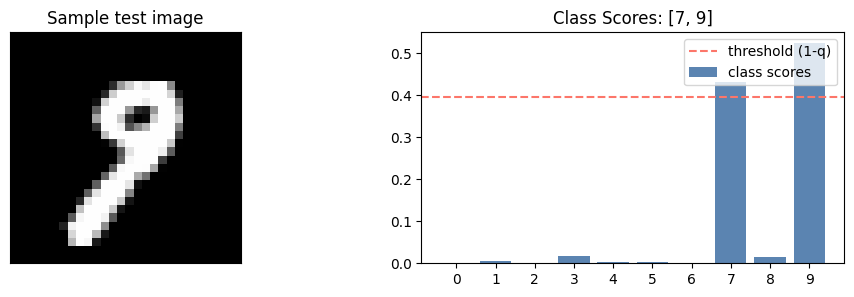

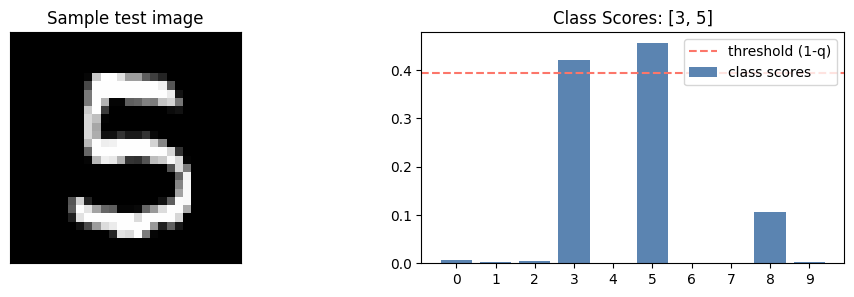

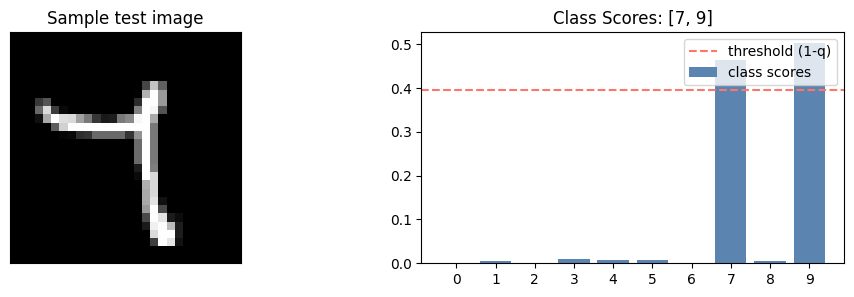

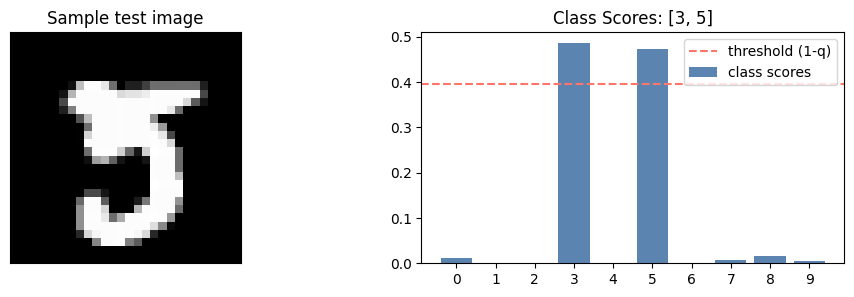

In [12]:
pred_sets = cp.predict_set(X_test)

# Graficar casos con múltiples clases
aux = plot_multi_class_predictions(X_test,cp, max_samples=3)